# 02. Baseline CNN 분류 모델

bbox crop 데이터셋을 사용해 간단한 CNN baseline을 학습하고 평가합니다.

In [1]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

ROOT = Path('C:/NEU-DET')
CROPS_DIR = ROOT / 'crops'
OUTPUT_FIGURES = ROOT / 'outputs' / 'figures'
OUTPUT_RESULTS = ROOT / 'outputs' / 'results'
OUTPUT_MODELS = ROOT / 'outputs' / 'models'

OUTPUT_FIGURES.mkdir(parents=True, exist_ok=True)
OUTPUT_RESULTS.mkdir(parents=True, exist_ok=True)
OUTPUT_MODELS.mkdir(parents=True, exist_ok=True)



In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device: cuda


In [3]:
# grayscale crop? 1?? tensor? ?????.
IMG_SIZE = 128
BATCH_SIZE = 32

train_tfms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

val_tfms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

train_ds = datasets.ImageFolder(CROPS_DIR / 'train', transform=train_tfms)
val_ds = datasets.ImageFolder(CROPS_DIR / 'validation', transform=val_tfms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

class_names = train_ds.classes
num_classes = len(class_names)
print(class_names)
print('train:', len(train_ds), 'validation:', len(val_ds))

['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
train: 3335 validation: 854


In [4]:
class BaselineCNN(nn.Module):
    """?? ??? CNN???. ?? ?? ??? ?? ?? baseline ?????."""
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

model = BaselineCNN(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [5]:
def run_one_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = 0.0
    all_preds, all_targets = [], []
    with torch.set_grad_enabled(is_train):
        for images, targets in loader:
            images, targets = images.to(device), targets.to(device)
            outputs = model(images)
            loss = criterion(outputs, targets)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * images.size(0)
            all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
    return total_loss / len(loader.dataset), accuracy_score(all_targets, all_preds)

EPOCHS = 20
best_val_acc = 0.0
best_model_path = OUTPUT_MODELS / 'baseline_cnn_best.pth'
history = []
for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = run_one_epoch(model, val_loader, criterion)
    history.append({'epoch': epoch, 'train_loss': train_loss, 'train_acc': train_acc, 'val_loss': val_loss, 'val_acc': val_acc})
    print(f'Epoch {epoch:02d}/{EPOCHS} | train_loss={train_loss:.4f} train_acc={train_acc:.4f} | val_loss={val_loss:.4f} val_acc={val_acc:.4f}')
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({'model_state_dict': model.state_dict(), 'class_names': class_names, 'img_size': IMG_SIZE}, best_model_path)
        print(f'  saved best model: {best_model_path}')
pd.DataFrame(history).to_csv(OUTPUT_RESULTS / 'baseline_training_log.csv', index=False, encoding='utf-8-sig')

Epoch 01/20 | train_loss=0.9862 train_acc=0.6675 | val_loss=1.2790 val_acc=0.5246
  saved best model: C:\NEU-DET\outputs\models\baseline_cnn_best.pth
Epoch 02/20 | train_loss=0.7558 train_acc=0.7430 | val_loss=0.7252 val_acc=0.7178
  saved best model: C:\NEU-DET\outputs\models\baseline_cnn_best.pth
Epoch 03/20 | train_loss=0.6144 train_acc=0.8069 | val_loss=0.9698 val_acc=0.6487
Epoch 04/20 | train_loss=0.5815 train_acc=0.8210 | val_loss=0.9202 val_acc=0.6639
Epoch 05/20 | train_loss=0.5249 train_acc=0.8351 | val_loss=0.7803 val_acc=0.6885
Epoch 06/20 | train_loss=0.4900 train_acc=0.8462 | val_loss=0.5744 val_acc=0.8232
  saved best model: C:\NEU-DET\outputs\models\baseline_cnn_best.pth
Epoch 07/20 | train_loss=0.4343 train_acc=0.8702 | val_loss=0.4969 val_acc=0.8337
  saved best model: C:\NEU-DET\outputs\models\baseline_cnn_best.pth
Epoch 08/20 | train_loss=0.4308 train_acc=0.8609 | val_loss=0.5002 val_acc=0.8700
  saved best model: C:\NEU-DET\outputs\models\baseline_cnn_best.pth
Epoc

In [6]:
checkpoint = torch.load(OUTPUT_MODELS / 'baseline_cnn_best.pth', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
all_preds, all_targets = [], []
with torch.no_grad():
    for images, targets in val_loader:
        outputs = model(images.to(device))
        all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
        all_targets.extend(targets.numpy())
acc = accuracy_score(all_targets, all_preds)
precision, recall, f1, _ = precision_recall_fscore_support(all_targets, all_preds, average='weighted', zero_division=0)
print(f'Accuracy={acc:.4f}, Precision={precision:.4f}, Recall={recall:.4f}, F1={f1:.4f}')
report_df = pd.DataFrame(classification_report(all_targets, all_preds, target_names=class_names, output_dict=True, zero_division=0)).transpose()
report_df.to_csv(OUTPUT_RESULTS / 'baseline_classification_report.csv', encoding='utf-8-sig')
report_df

Accuracy=0.8934, Precision=0.8945, Recall=0.8934, F1=0.8930


,precision,recall,f1-score,support
crazing,0.915254,1.000000,0.955752,162.000000
inclusion,0.822086,0.842767,0.832298,159.000000
patches,0.935484,0.901554,0.918206,193.000000
pitted_surface,0.907895,0.793103,0.846626,87.000000
rolled-in_scale,0.936508,0.893939,0.914729,132.000000
scratches,0.841270,0.876033,0.858300,121.000000
accuracy,0.893443,0.893443,0.893443,0.893443
macro avg,0.893083,0.884566,0.887652,854.000000
weighted avg,0.894533,0.893443,0.893016,854.000000


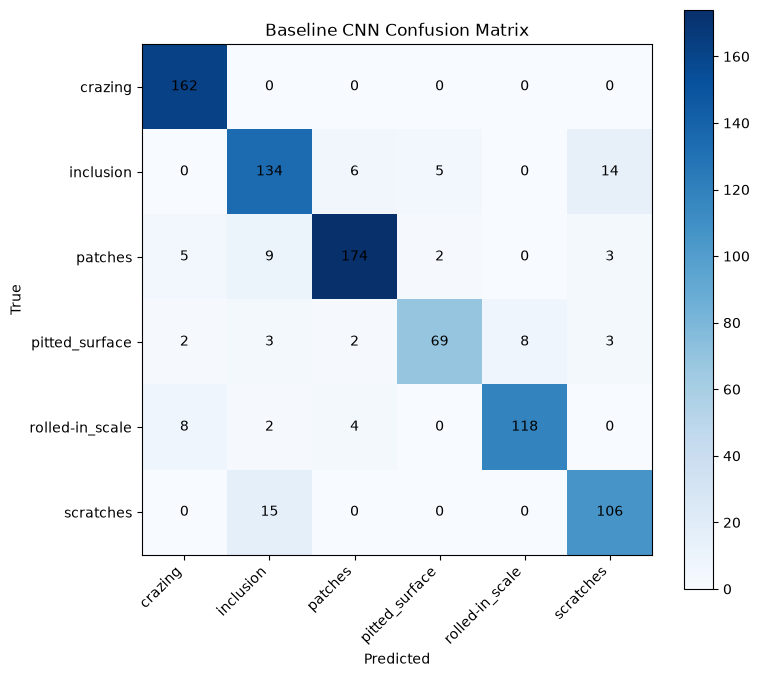

In [7]:
cm = confusion_matrix(all_targets, all_preds)
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(num_classes), class_names, rotation=45, ha='right')
ax.set_yticks(range(num_classes), class_names)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Baseline CNN Confusion Matrix')
for i in range(num_classes):
    for j in range(num_classes):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='black')
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES / 'baseline_confusion_matrix.png', dpi=150)
plt.show()

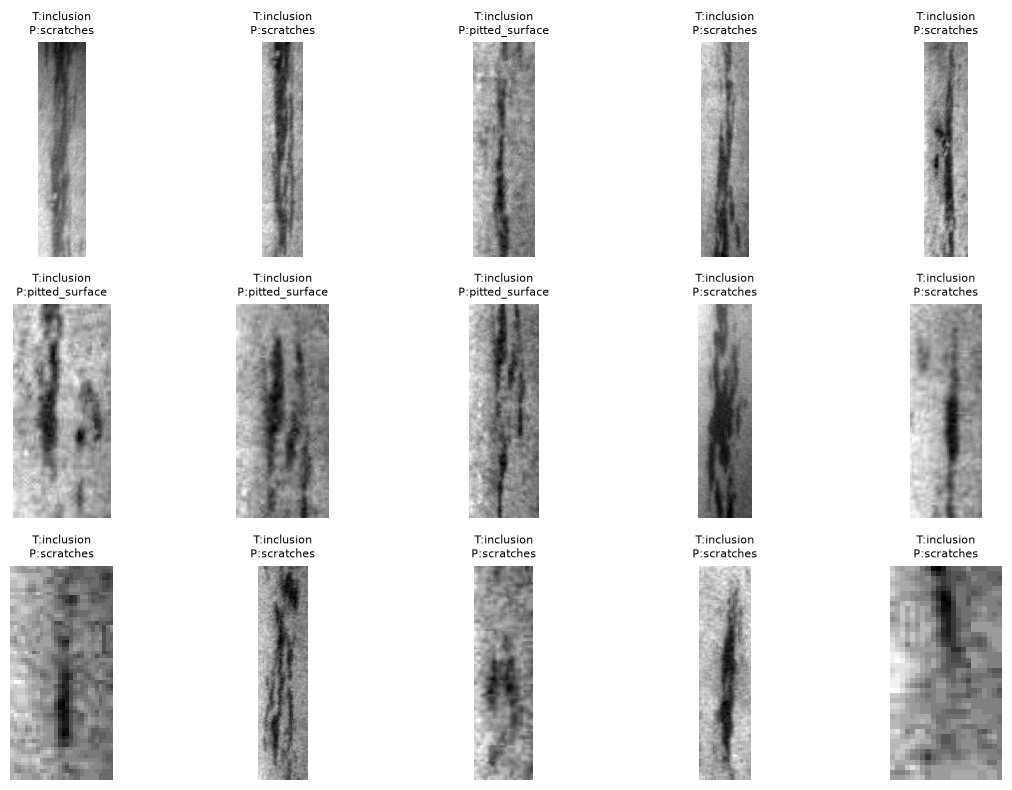

In [8]:
mis_idx = [i for i, (t, p) in enumerate(zip(all_targets, all_preds)) if t != p]
fig, axes = plt.subplots(3, 5, figsize=(12, 8))
axes = axes.flatten()
for ax, idx in zip(axes, mis_idx[:15]):
    path, _ = val_ds.samples[idx]
    img = Image.open(path).convert('L')
    ax.imshow(img, cmap='gray')
    ax.set_title(f"T:{class_names[all_targets[idx]]}\nP:{class_names[all_preds[idx]]}", fontsize=8)
    ax.axis('off')
for ax in axes[len(mis_idx[:15]):]:
    ax.axis('off')
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES / 'misclassified_samples.png', dpi=150)
plt.show()